# AmbiTap — real-time DSP behavior

The other notebooks verify the *math* layer (spherical harmonics, decoder
matrices, HRTFs). This one verifies the *runtime* layer — the machinery that
makes AmbiTap safe to automate while audio is running. Every claim below is
stated in the library's docs and machine-checked here against the **actual
C++ processors** through the C ABI (`tools/capi/`, via `ambitap_py.py`):

1. **Parameter smoothing** — `dsp::encoder` coefficient changes ramp linearly
   over exactly 128 samples (`k_smoothing_samples`); no clicks, no torn tables.
2. **Matrix crossfades** — `dsp::decoder` adopts a rebuilt decode matrix by
   crossfading over exactly 256 samples (`k_fade_samples`).
3. **Doppler glide** — `dsp::doppler` slews its delay (one-pole, ~1024-sample
   time constant), so distance modulation produces the physical pitch shift
   and distance *jumps* produce a glide instead of a click.
4. **Spatial compressor** — the W-keyed gain computer realizes the ideal
   static curve (slope 1 below threshold, 1/ratio above) with the configured
   attack/release dynamics.

If this notebook runs to the end, those claims hold for the code as built.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ambitap_py as at

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = at.PALETTE
print(f"AmbiTap C ABI loaded — channels(order 3) = {at.channel_count(3)}")


AmbiTap C ABI loaded — channels(order 3) = 16


## 1. Encoder parameter smoothing

`encoder::set_direction()` retargets the SH coefficient table; the audio
thread ramps each coefficient linearly over 128 samples. We encode a constant
1.0 input (so the output *is* the coefficient trajectory), retarget from
front to hard left at sample 100, and watch every channel glide.


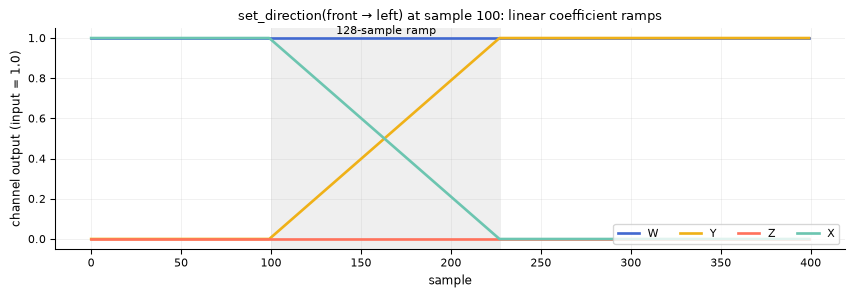

In [2]:
K_SMOOTH = 128           # dsp::util k_smoothing_samples
order, change_at, n = 1, 100, 400
ramp = at.encoder_ramp(order, 0.0, 0.0, np.pi / 2, 0.0, change_at, n)

names = ["W", "Y", "Z", "X"]
fig, ax = plt.subplots()
for ch in range(4):
    ax.plot(ramp[ch], color=PAL[ch], lw=2, label=names[ch])
ax.axvspan(change_at, change_at + K_SMOOTH, color="0.5", alpha=0.12, lw=0)
ax.annotate("128-sample ramp", (change_at + K_SMOOTH / 2, 1.02), ha="center", fontsize=8)
ax.set(xlabel="sample", ylabel="channel output (input = 1.0)",
       title="set_direction(front → left) at sample 100: linear coefficient ramps")
ax.legend(ncols=4, loc="lower right")
fig.tight_layout()


In [3]:
# VERIFY: exact endpoints, exact ramp length, exact linearity.
y_front = at.evaluate_sh(order, 0.0, 0.0)
y_left = at.evaluate_sh(order, np.pi / 2, 0.0)

assert np.allclose(ramp[:, :change_at], y_front[:, None], atol=1e-6), \
    "output before the change must equal the front-direction SH coefficients"
assert np.allclose(ramp[:, change_at + K_SMOOTH - 1:], y_left[:, None], atol=1e-6), \
    "the ramp must be complete after exactly 128 samples"
assert not np.allclose(ramp[:, change_at + K_SMOOTH - 3], y_left, atol=1e-4), \
    "the ramp must not be complete early"

# Linear: second difference vanishes inside the ramp on every channel.
seg = ramp[:, change_at:change_at + K_SMOOTH]
assert np.abs(np.diff(seg, 2, axis=1)).max() < 1e-5, "ramp must be linear"

# Click-free: the largest per-sample step is the parameter change spread
# over 128 samples — compare with the instantaneous jump.
jump = np.abs(y_left - y_front).max()
step = np.abs(np.diff(ramp, axis=1)).max()
print(f"instantaneous jump would be {jump:.3f}; largest actual step {step:.4f} "
      f"(= jump/128 = {jump / K_SMOOTH:.4f})")
assert step < jump / K_SMOOTH * 1.01
print("encoder smoothing verified: linear, exactly 128 samples, click-free")


instantaneous jump would be 1.000; largest actual step 0.0078 (= jump/128 = 0.0078)
encoder smoothing verified: linear, exactly 128 samples, click-free


## 2. Decoder matrix crossfade

Decode matrices are rebuilt on a worker thread (SVD is not real-time-safe)
and published wait-free. When the audio thread adopts a new matrix it
crossfades over 256 samples against the previous one. We drive a constant
HOA frame (a settled order-3 source at azimuth 23°) through an octagon
decoder and switch the algorithm from mode-matching to EPAD mid-stream —
the capture starts at the first crossfade sample.


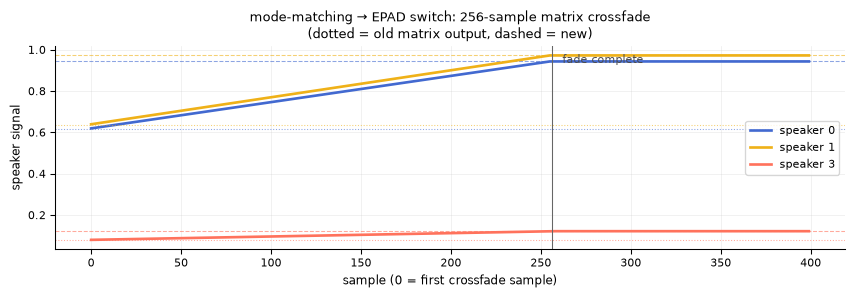

In [4]:
K_FADE = 256             # dsp::decoder::k_fade_samples
az, el = at.layout("octagon")
hoa = at.evaluate_sh(3, np.radians(23), 0.0)
xf = at.decoder_crossfade(3, az, el, "mode_match", "epad", hoa, 400)

D_from = at.decoder_matrix("mode_match", 3, az, el)
D_to = at.decoder_matrix("epad", 3, az, el)
g_from, g_to = D_from @ hoa, D_to @ hoa

fig, ax = plt.subplots()
for i, spk in enumerate([0, 1, 3]):
    ax.plot(xf[spk], color=PAL[i], lw=2, label=f"speaker {spk}")
    ax.axhline(g_from[spk], color=PAL[i], lw=0.8, ls=":", alpha=0.6)
    ax.axhline(g_to[spk], color=PAL[i], lw=0.8, ls="--", alpha=0.6)
ax.axvline(K_FADE, color="0.4", lw=0.8)
ax.annotate("fade complete", (K_FADE + 6, ax.get_ylim()[1] * 0.92), fontsize=8, color="0.3")
ax.set(xlabel="sample (0 = first crossfade sample)", ylabel="speaker signal",
       title="mode-matching → EPAD switch: 256-sample matrix crossfade\n"
             "(dotted = old matrix output, dashed = new)")
ax.legend(loc="center right")
fig.tight_layout()


In [5]:
# VERIFY: the fade is the documented linear interpolation, completes at 256,
# and bounds the per-sample step to 1/256th of a hard switch.
alpha = (np.arange(K_FADE) + 1.0) / K_FADE
expected = g_from[:, None] + (g_to - g_from)[:, None] * alpha
assert np.abs(xf[:, :K_FADE] - expected).max() < 1e-4, "crossfade must be linear in alpha"
assert np.abs(xf[:, K_FADE:] - g_to[:, None]).max() < 1e-5, "settled output must be D_new @ hoa"

hard_jump = np.abs(g_to - g_from).max()
actual_step = np.abs(np.diff(xf, axis=1)).max()
print(f"hard switch would step {hard_jump:.3f}; crossfade max step {actual_step:.5f} "
      f"(= jump/256 = {hard_jump / K_FADE:.5f})")
assert actual_step < hard_jump / K_FADE * 1.01
print("decoder crossfade verified: linear, exactly 256 samples, click-free")


hard switch would step 0.335; crossfade max step 0.00131 (= jump/256 = 0.00131)
decoder crossfade verified: linear, exactly 256 samples, click-free


## 3. Doppler pitch shift and glide

`dsp::doppler` models source-distance time-of-flight. The physics check: a
source receding at speed $v$ shifts a tone by the factor $1 - v/c$; one
approaching by $1 + v/c$. We move a 1 kHz tone at $v = 0.1\,c$ (34.3 m/s)
both ways and measure the received frequency, then *step* the distance and
confirm the delay slew turns the discontinuity into a pitch glide.


/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:8647: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


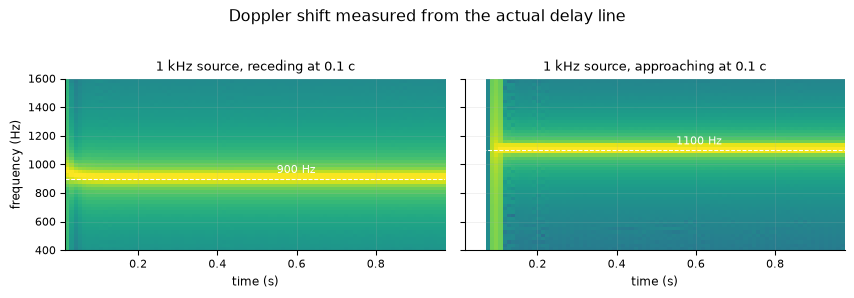

In [6]:
fs, f0, c = 48000, 1000.0, 343.0
t = np.arange(fs) / fs                       # 1 s
mono = np.sin(2 * np.pi * f0 * t).astype(np.float32)

v = 0.1 * c
away = at.doppler_process(mono, np.linspace(1, 1 + v, fs).astype(np.float32),
                          sample_rate=fs, max_distance=50)
toward = at.doppler_process(mono, np.linspace(1 + v, 1, fs).astype(np.float32),
                            sample_rate=fs, max_distance=50)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.0), sharey=True)
for ax, y, expect, label in [(axes[0], away, f0 * (1 - v / c), "receding at 0.1 c"),
                             (axes[1], toward, f0 * (1 + v / c), "approaching at 0.1 c")]:
    ax.specgram(y, NFFT=2048, Fs=fs, noverlap=1536, cmap="viridis")
    ax.axhline(expect, color="w", lw=0.8, ls="--")
    ax.annotate(f"{expect:.0f} Hz", (0.55, expect + 40), color="w", fontsize=8)
    ax.set(ylim=(400, 1600), xlabel="time (s)", title=f"1 kHz source, {label}")
axes[0].set_ylabel("frequency (Hz)")
fig.suptitle("Doppler shift measured from the actual delay line", y=1.02)
fig.tight_layout()


In [7]:
# VERIFY: measured frequency (zero-crossing count in the steady middle
# region) matches 1 -/+ v/c to better than 1%.
def measured_freq(y, lo, hi):
    seg = y[lo:hi]
    zc = np.where((seg[:-1] < 0) & (seg[1:] >= 0))[0]
    return fs / np.mean(np.diff(zc))

f_away = measured_freq(away, 20000, 40000)
f_toward = measured_freq(toward, 20000, 40000)
print(f"receding:    measured {f_away:7.2f} Hz, theory {f0 * (1 - v / c):7.2f} Hz")
print(f"approaching: measured {f_toward:7.2f} Hz, theory {f0 * (1 + v / c):7.2f} Hz")
assert abs(f_away - f0 * (1 - v / c)) / f0 < 0.01
assert abs(f_toward - f0 * (1 + v / c)) / f0 < 0.01
print("Doppler shift verified against 1 ± v/c")


receding:    measured  899.98 Hz, theory  900.00 Hz
approaching: measured 1100.05 Hz, theory 1100.00 Hz
Doppler shift verified against 1 ± v/c


before step 1000.0 Hz, during glide 299.8 Hz, after 1000.0 Hz
distance jump verified: glide, with exact pitch recovery


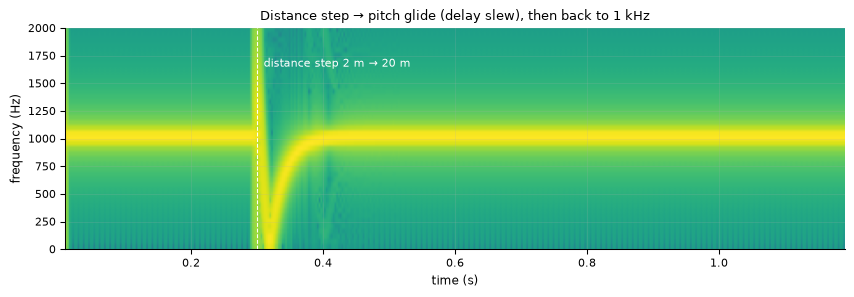

In [8]:
# A distance JUMP (2 m -> 20 m at t = 0.3 s) must glide, not click: the delay
# slews with a ~1024-sample one-pole, so the pitch dips and recovers.
n = int(1.2 * fs)
t2 = np.arange(n) / fs
mono2 = np.sin(2 * np.pi * f0 * t2).astype(np.float32)
dist = np.full(n, 2.0, np.float32)
dist[int(0.3 * fs):] = 20.0
y = at.doppler_process(mono2, dist, sample_rate=fs, max_distance=30)

fig, ax = plt.subplots()
ax.specgram(y, NFFT=1024, Fs=fs, noverlap=896, cmap="viridis")
ax.axvline(0.3, color="w", lw=0.8, ls="--")
ax.annotate("distance step 2 m → 20 m", (0.31, 1650), color="w", fontsize=8)
ax.set(ylim=(0, 2000), xlabel="time (s)", ylabel="frequency (Hz)",
       title="Distance step → pitch glide (delay slew), then back to 1 kHz")
fig.tight_layout()

f_pre = measured_freq(y, int(0.1 * fs), int(0.28 * fs))
f_dip = measured_freq(y, int(0.31 * fs), int(0.34 * fs))
f_post = measured_freq(y, int(0.9 * fs), n)
print(f"before step {f_pre:.1f} Hz, during glide {f_dip:.1f} Hz, after {f_post:.1f} Hz")
assert abs(f_pre - f0) / f0 < 0.01 and abs(f_post - f0) / f0 < 0.01
assert f_dip < 0.7 * f0, "the step must produce a deep transient pitch glide"
print("distance jump verified: glide, with exact pitch recovery")


## 4. Spatial compressor

The compressor detects level on W only and applies one gain to all channels
(the spatial image is untouched by construction — every channel is scaled by
the same scalar). Here we verify the gain computer itself: the static
transfer curve and the attack/release dynamics.


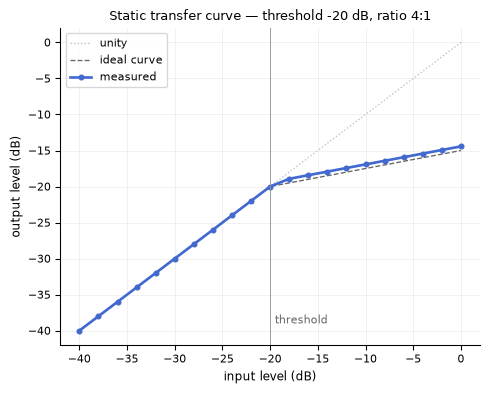

In [9]:
fs = 48000
thr, ratio = -20.0, 4.0
levels = np.arange(-40.0, 0.5, 2.0)
t = np.arange(int(0.3 * fs)) / fs
out_db = []
for L in levels:
    w = (10 ** (L / 20) * np.sin(2 * np.pi * 997 * t)).astype(np.float32)
    g = at.compressor_gain(w, sample_rate=fs, threshold_db=thr, ratio=ratio)
    y = w * g
    seg = y[len(y) // 2:]                     # steady state
    out_db.append(20 * np.log10(np.sqrt(np.mean(seg**2)) * np.sqrt(2)))
out_db = np.array(out_db)

ideal = np.where(levels <= thr, levels, thr + (levels - thr) / ratio)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.plot(levels, levels, color="0.75", lw=1, ls=":", label="unity")
ax.plot(levels, ideal, color="0.4", lw=1, ls="--", label="ideal curve")
ax.plot(levels, out_db, color=PAL[0], lw=2, marker="o", ms=3.5, label="measured")
ax.axvline(thr, color="0.6", lw=0.7)
ax.annotate("threshold", (thr + 0.5, -39), fontsize=8, color="0.4")
ax.set(xlabel="input level (dB)", ylabel="output level (dB)",
       title=f"Static transfer curve — threshold {thr:.0f} dB, ratio {ratio:.0f}:1")
ax.legend()
fig.tight_layout()


In [10]:
# VERIFY: slope 1 below threshold (identity), slope 1/ratio above.
below, above = levels <= thr - 8, levels >= thr + 8
s_below = np.polyfit(levels[below], out_db[below], 1)[0]
s_above = np.polyfit(levels[above], out_db[above], 1)[0]
print(f"slope below threshold: {s_below:.4f} (ideal 1.0)")
print(f"slope above threshold: {s_above:.4f} (ideal 1/{ratio:.0f} = {1 / ratio:.4f})")
assert abs(s_below - 1.0) < 0.02
assert abs(s_above - 1.0 / ratio) < 0.02
assert np.abs(out_db[below] - levels[below]).max() < 0.1, "identity below threshold"
print("static curve verified")


slope below threshold: 1.0000 (ideal 1.0)
slope above threshold: 0.2500 (ideal 1/4 = 0.2500)
static curve verified


steady gain 0.246; attack tau ≈ 3.7 ms, release tau ≈ 143.3 ms
attack/release dynamics verified


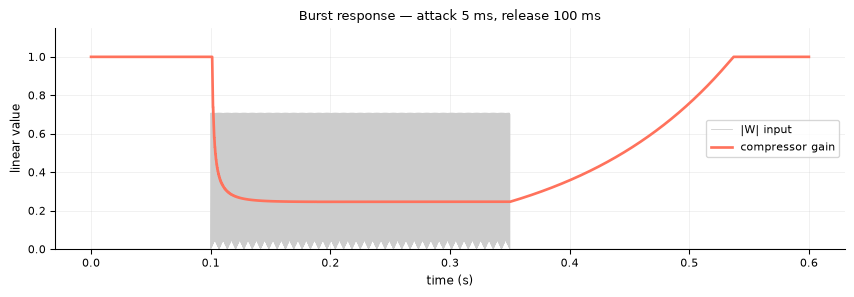

In [11]:
# Dynamics: a -3 dB tone burst. The gain must fall on the attack clock and
# recover on the (slower) release clock.
attack_s, release_s = 0.005, 0.1
n = int(0.6 * fs)
w = np.zeros(n, dtype=np.float32)
i0, i1 = int(0.1 * fs), int(0.35 * fs)
tb = np.arange(i1 - i0) / fs
w[i0:i1] = (10 ** (-3 / 20) * np.sin(2 * np.pi * 997 * tb)).astype(np.float32)
g = at.compressor_gain(w, sample_rate=fs, threshold_db=thr, ratio=ratio,
                       attack_s=attack_s, release_s=release_s)

tt = np.arange(n) / fs
fig, ax = plt.subplots()
ax.plot(tt, np.abs(w), color="0.8", lw=0.6, label="|W| input")
ax.plot(tt, g, color=PAL[2], lw=2, label="compressor gain")
ax.set(xlabel="time (s)", ylabel="linear value", ylim=(0, 1.15),
       title=f"Burst response — attack {attack_s * 1e3:.0f} ms, release {release_s * 1e3:.0f} ms")
ax.legend(loc="center right")
fig.tight_layout()

# 63%-of-final-reduction time on attack; 63%-recovered time on release.
g_steady = g[i1 - int(0.01 * fs)]
gr = 1 - g_steady
t_att = np.argmax(g[i0:] <= 1 - 0.63 * gr) / fs
t_rel = np.argmax(g[i1:] >= 1 - 0.37 * gr) / fs
print(f"steady gain {g_steady:.3f}; attack tau ≈ {t_att * 1e3:.1f} ms, "
      f"release tau ≈ {t_rel * 1e3:.1f} ms")
assert 0.001 < t_att < 3 * attack_s, "attack must act on the attack clock"
assert release_s / 2 < t_rel < 3 * release_s, "release must act on the release clock"
assert t_rel > 5 * t_att, "release must be much slower than attack, as configured"
print("attack/release dynamics verified")


## Summary

Verified in this notebook, against the compiled processors:

- `dsp::encoder` coefficient changes ramp **linearly over exactly 128
  samples**; the largest output step is the parameter jump / 128.
- `dsp::decoder` adopts rebuilt matrices with a **linear 256-sample
  crossfade**; settled output equals `D_new @ hoa` exactly.
- `dsp::doppler` reproduces the physical shift $f_0(1 \pm v/c)$ to < 1%,
  and distance steps glide (delay slew) instead of clicking.
- `dsp::spatial_compressor` realizes the ideal static curve (slopes 1 and
  1/ratio, identity below threshold) with attack/release on the configured
  clocks.

Together with the TSan-checked thread-safety tests in
`tests/test_dsp_threads.cpp` and the allocation-free proof in
`tests/test_rt_safety.cpp`, this is the library's real-time contract:
*automatable, click-free, wait-free*.
